# D009 — 데이터 품질 진단 및 EDA 보고서
## KBO 팬 멤버십 데이터

**사용 데이터**: 외부 데이터 (선택 2) — KBO 팬 멤버십/구매 실습용 샘플 데이터
**데이터 위치**: `data/kbo_fan_data_sample.csv`
**출처 노트**: `data/source_note.md` 참고 (공개 URL 없는 커리큘럼 제공 실습 데이터, email 컬럼은 개인정보 보호를 위해 사전 제거)

---

### 진행 흐름
```
데이터 선택 → 데이터 개요 파악 → 품질 진단 → 정제 → 정제 전후 비교
→ EDA → 한계와 후속 질문
```


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# 한글 폰트 (없으면 기본 폰트로 대체되어도 실행에는 문제 없음)
for name in ["NanumGothic", "AppleGothic", "Malgun Gothic"]:
    if any(name in f.name for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = name
        break
plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = "data/kbo_fan_data_sample.csv"
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

## 1. 데이터 개요

- **출처**: 커리큘럼 실습용 합성 데이터 (Kaggle/공공데이터포털 데이터 아님, 자세한 내용은 `data/source_note.md`)
- **관측 단위**: 한 행 = 한 명의 KBO 팬(멤버십 가입 고객)
- **분석 질문**: *구단·지역·멤버십 등급에 따라 팬들의 지출·관람 패턴에 차이가 있는가?*

| 컬럼 | 의미 |
|---|---|
| customer_id | 팬 고유 ID (합성 식별자) |
| age | 나이 |
| region | 거주 지역 |
| favorite_team | 응원 구단 |
| join_date | 멤버십 가입일 |
| membership_tier | 멤버십 등급 (Bronze/Silver/Gold/VIP) |
| season_ticket_yn | 시즌권 보유 여부 |
| purchase_count | 구매(굿즈/티켓 등) 횟수 |
| total_spent | 총 지출액 |
| last_purchase_date | 최근 구매일 |
| sns_follow_yn | 구단 SNS 팔로우 여부 |
| referral_source | 가입 유입 경로 |
| attended_games | 관람 경기 수 |
| favorite_seat_section | 선호 좌석 구역 |

**특히 중요하게 볼 컬럼**: `favorite_team`, `membership_tier`, `region` (범주별 비교 기준) / `total_spent`, `attended_games`, `purchase_count` (핵심 수치 지표)


In [2]:
raw = pd.read_csv(DATA_PATH)
print("shape:", raw.shape)
print()
print(raw.dtypes)
raw.head()

shape: (5075, 14)

customer_id                  str
age                      float64
region                       str
favorite_team                str
join_date                    str
membership_tier              str
season_ticket_yn             str
purchase_count           float64
total_spent              float64
last_purchase_date           str
sns_follow_yn            float64
referral_source              str
attended_games             int64
favorite_seat_section        str
dtype: object


,customer_id,age,region,favorite_team,join_date,membership_tier,season_ticket_yn,purchase_count,total_spent,last_purchase_date,sns_follow_yn,referral_source,attended_games,favorite_seat_section
0,KBOFAN0002254,42.0,Seoul City,doosan bears,12/31/2018,NaN,1,5.0,213732.0,2025-03-08,1.0,SNS,13,Outfield
1,KBOFAN0000173,62.0,Seoul,Doosan Bears,2022-12-06,Bronze,0,5.0,155392.0,2025.08.07,NaN,Advertisement,11,Infield
2,KBOFAN0001339,16.0,Busan City,SSGLanders,2022-03-16,Bronze,Y,7.0,355804.0,2024.10.22,0.0,Offline Event,11,Family Zone
3,KBOFAN0003440,61.0,Incheon-si,DoosanBears,2020-04-16,VIP,N,5.0,306801.0,2025-10-13,1.0,Club Website,6,Premium Box
4,KBOFAN0000214,32.0,SEOUL,KIA Tigers,09/08/2017,Silver,Yes,5.0,200056.0,2025-03-24,1.0,Advertisement,7,Outfield


## 2. 데이터 품질 진단

`quality_report_full()` 함수로 구조·결측·중복·타입·이상치를 한 번에 진단합니다.

In [3]:
def quality_report_full(df: pd.DataFrame, missing_threshold: float = 30.0) -> pd.DataFrame:
    """구조·결측·중복·타입·이상치를 한 표로 진단한다."""
    rows = []
    n = len(df)
    for col in df.columns:
        s = df[col]
        dtype = str(s.dtype)
        n_missing = s.isna().sum()
        missing_pct = round(n_missing / n * 100, 2)

        maybe_datetime = False
        if s.dtype == object:
            sample = s.dropna().astype(str).head(50)
            try:
                parsed = pd.to_datetime(sample, errors="coerce", format="mixed")
                maybe_datetime = parsed.notna().mean() > 0.8
            except Exception:
                maybe_datetime = False

        outlier_pct = np.nan
        if pd.api.types.is_numeric_dtype(s):
            q1, q3 = s.quantile(0.25), s.quantile(0.75)
            iqr = q3 - q1
            lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            outlier_pct = round(((s < lo) | (s > hi)).mean() * 100, 2)

        rows.append({
            "column": col, "dtype": dtype, "n_missing": n_missing,
            "missing_pct": missing_pct,
            "flag_high_missing": "\u26a0" if missing_pct >= missing_threshold else "",
            "n_unique": s.nunique(dropna=True),
            "maybe_datetime": maybe_datetime,
            "outlier_pct_iqr": outlier_pct,
        })
    report = pd.DataFrame(rows)
    report.attrs["n_rows"] = n
    report.attrs["n_cols"] = df.shape[1]
    report.attrs["n_duplicates_full"] = df.duplicated().sum()
    report.attrs["n_duplicates_by_customer_id"] = (
        df.duplicated(subset=["customer_id"]).sum() if "customer_id" in df.columns else None
    )
    return report

q_report = quality_report_full(raw)
print("전체 행 수:", q_report.attrs["n_rows"], "| 전체 열 수:", q_report.attrs["n_cols"])
print("완전 중복 행 수:", q_report.attrs["n_duplicates_full"])
print("customer_id 기준 중복 행 수:", q_report.attrs["n_duplicates_by_customer_id"])
q_report

전체 행 수: 5075 | 전체 열 수: 14
완전 중복 행 수: 50
customer_id 기준 중복 행 수: 75


,column,dtype,n_missing,missing_pct,flag_high_missing,n_unique,maybe_datetime,outlier_pct_iqr
0,customer_id,str,0,0.00,,5000,False,NaN
1,age,float64,150,2.96,,64,False,0.14
2,region,str,204,4.02,,70,False,NaN
3,favorite_team,str,101,1.99,,50,False,NaN
4,join_date,str,0,0.00,,4157,False,NaN
5,membership_tier,str,255,5.02,,4,False,NaN
6,season_ticket_yn,str,0,0.00,,8,False,NaN
7,purchase_count,float64,99,1.95,,19,False,0.06
8,total_spent,float64,0,0.00,,4960,False,2.33
9,last_purchase_date,str,0,0.00,,2851,False,NaN


**진단 결과 해석**

- 결측률이 가장 높은 컬럼은 `sns_follow_yn`(약 10%), 그 뒤로 `membership_tier`(5%), `region`/`favorite_seat_section`(4%대)이 이어집니다.
- 완전 중복 행 50건 + `customer_id` 기준 중복 75건 — 즉 25건은 **같은 사람인데 값이 다른** 스냅샷 충돌입니다.
- `age`, `purchase_count`, `total_spent`, `attended_games`에서 IQR 기준 이상치가 관찰됩니다 (특히 `total_spent`가 2%대로 가장 높음).
- `maybe_datetime`이 `join_date`/`last_purchase_date`에서는 표기가 4종류로 섞여 있어 정확히 잡히지 않을 수 있으므로, 아래에서 직접 표기 패턴을 확인합니다.


In [4]:
# 표기 혼재 직접 확인 — region, favorite_team, season_ticket_yn, 날짜 포맷
print("region 표기 종류 수:", raw["region"].dropna().nunique())
print(raw["region"].dropna().str.strip().str.lower().value_counts().head(6))
print()
print("favorite_team 표기 종류 수:", raw["favorite_team"].dropna().nunique())
print()
print("season_ticket_yn 표기:", raw["season_ticket_yn"].value_counts(dropna=False).to_dict())
print()
print("join_date 표기 샘플:", raw["join_date"].sample(6, random_state=1).tolist())

region 표기 종류 수: 70
region
daegu       387
cheongju    365
busan       357
daejeon     347
incheon     344
jeju        340
Name: count, dtype: int64

favorite_team 표기 종류 수: 50

season_ticket_yn 표기: {'n': 674, '1': 637, 'No': 636, 'y': 636, 'N': 633, 'Yes': 631, '0': 623, 'Y': 605}

join_date 표기 샘플: ['2022.12.30', '2022-03-21', '2016-07-16', '2018.08.11', '12-01-2018', '10/23/2016']


## 3. 정제 과정과 판단 근거

중복 → 문자열 → 날짜 → 이상치 → 결측치 순서로 정제합니다. 각 단계를 함수로 분리하고 `.pipe()`로 연결합니다.


In [5]:
DECISION_LOG = []

def log_decision(step, reason, result):
    DECISION_LOG.append({"단계": step, "판단 근거": reason, "처리 결과": result})


def drop_duplicates_step(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    full_dup = df.duplicated().sum()
    df = df.drop_duplicates()

    df["_last_purchase_tmp"] = pd.to_datetime(df["last_purchase_date"].apply(_parse_date), errors="coerce")
    df = (df.sort_values("_last_purchase_tmp")
            .drop_duplicates(subset=["customer_id"], keep="last")
            .drop(columns="_last_purchase_tmp"))
    after = len(df)
    log_decision(
        "1. 중복 행 처리",
        f"완전 중복 {full_dup}건 제거. 이후 남은 동일 customer_id {before - full_dup - after}건은 같은 고객의 "
        f"서로 다른 시점 스냅샷으로 판단하여, last_purchase_date가 가장 최근인 행만 채택.",
        f"{before}행 -> {after}행",
    )
    return df.reset_index(drop=True)

In [6]:
_REGION_SUFFIX = re.compile(r"(-si|\s*city)$", flags=re.IGNORECASE)

def clean_strings_step(df: pd.DataFrame) -> pd.DataFrame:
    before_region = df["region"].dropna().nunique()
    before_team = df["favorite_team"].dropna().nunique()

    df["region"] = (
        df["region"].astype("string").str.strip().str.lower()
        .str.replace(_REGION_SUFFIX, "", regex=True).str.strip().str.title()
    )

    team_key = df["favorite_team"].astype("string").str.replace(r"\s+", "", regex=True).str.lower()
    team_canonical = {
        "doosanbears": "Doosan Bears", "lgtwins": "LG Twins", "kiatigers": "KIA Tigers",
        "samsunglions": "Samsung Lions", "ssglanders": "SSG Landers", "lottegiants": "Lotte Giants",
        "kiwoomheroes": "Kiwoom Heroes", "ncdinos": "NC Dinos", "hanwhaeagles": "Hanwha Eagles",
        "ktwiz": "KT Wiz",
    }
    df["favorite_team"] = team_key.map(team_canonical)

    yn_map = {"y": 1, "yes": 1, "1": 1, 1: 1, "n": 0, "no": 0, "0": 0, 0: 0}
    df["season_ticket_yn"] = df["season_ticket_yn"].astype(str).str.strip().str.lower().map(yn_map)

    after_region = df["region"].dropna().nunique()
    after_team = df["favorite_team"].dropna().nunique()
    log_decision(
        "2. 문자열 공백 제거 및 표기 통일",
        "region은 대소문자·공백·'-si'/'city' 접미사가 혼재해 같은 지역이 여러 값으로 흩어져 있었음. "
        "favorite_team도 공백·대소문자·붙임표기가 혼재. season_ticket_yn은 Y/N 표기가 8종이라 0/1로 통일.",
        f"region {before_region}종 -> {after_region}종, favorite_team {before_team}종 -> {after_team}종, "
        f"season_ticket_yn 8종 -> 2종",
    )
    return df

In [7]:
def _parse_date(s):
    """4종 날짜 포맷(월-일 순서가 서로 다름)을 표기 패턴별로 구분해 명시적으로 파싱."""
    if pd.isna(s):
        return pd.NaT
    s = str(s)
    if re.match(r"^\d{4}-\d{2}-\d{2}$", s):
        return pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
    if re.match(r"^\d{4}\.\d{2}\.\d{2}$", s):
        return pd.to_datetime(s, format="%Y.%m.%d", errors="coerce")
    if re.match(r"^\d{2}/\d{2}/\d{4}$", s):
        return pd.to_datetime(s, format="%m/%d/%Y", errors="coerce")
    if re.match(r"^\d{2}-\d{2}-\d{4}$", s):
        return pd.to_datetime(s, format="%d-%m-%Y", errors="coerce")
    return pd.to_datetime(s, errors="coerce")


def parse_dates_step(df: pd.DataFrame) -> pd.DataFrame:
    for col in ["join_date", "last_purchase_date"]:
        df[col] = df[col].apply(_parse_date)
    log_decision(
        "3. 날짜 형식 변환",
        "join_date/last_purchase_date에 4가지 표기(YYYY-MM-DD, YYYY.MM.DD, MM/DD/YYYY, DD-MM-YYYY)가 혼재. "
        "'/' 포맷은 월-일-년, '-' 포맷은 일-월-년으로 순서가 서로 반대여서 format='mixed' 일괄 파싱은 오류 위험이 있어 "
        "표기 패턴을 정규식으로 먼저 구분한 뒤 포맷별로 명시적으로 파싱.",
        "두 컬럼 모두 object -> datetime64[ns]",
    )
    return df

In [8]:
def handle_outliers_step(df: pd.DataFrame) -> pd.DataFrame:
    n_age_bad = ((df["age"] < 0) | (df["age"] > 100)).sum()
    df.loc[(df["age"] < 0) | (df["age"] > 100), "age"] = np.nan

    n_pc_bad = (df["purchase_count"] < 0).sum()
    df.loc[df["purchase_count"] < 0, "purchase_count"] = np.nan

    q1, q3 = df["total_spent"].quantile(0.25), df["total_spent"].quantile(0.75)
    iqr = q3 - q1
    hi = q3 + 1.5 * iqr
    n_high = (df["total_spent"] > hi).sum()

    log_decision(
        "4. 이상치 및 음수 값 처리",
        f"age는 0~100세 범위를 벗어날 수 없음(음수·150세 발견) -> {n_age_bad}건 결측 전환. "
        f"purchase_count 음수 {n_pc_bad}건도 결측 전환(구매 횟수는 음수가 될 수 없음). "
        f"total_spent 상단 이상치 {n_high}건은 IQR로는 잡히지만 VIP 고액 소비일 수 있어 도메인 판단으로 유지(제거하지 않음).",
        f"age {n_age_bad}건, purchase_count {n_pc_bad}건 -> NaN / total_spent {n_high}건 유지",
    )
    return df


def handle_missing_step(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    n_pc_missing = df["purchase_count"].isna().sum()
    df = df.dropna(subset=["purchase_count"])

    for col in ["region", "favorite_team", "membership_tier", "referral_source", "favorite_seat_section"]:
        df[col] = df[col].fillna("Unknown")
    df["sns_follow_yn"] = df["sns_follow_yn"].fillna(-1).astype(int)

    after = len(df)
    log_decision(
        "5. 결측치 처리",
        f"purchase_count는 구매 KPI의 핵심 지표라 결측이면 집계 자체를 신뢰할 수 없어 결측 {n_pc_missing}행을 제거. "
        f"반면 age·region·favorite_team·membership_tier·referral_source·favorite_seat_section·sns_follow_yn은 "
        f"인구통계/부가정보라 행을 지우면 정작 필요한 지출 데이터까지 함께 사라지므로 'Unknown'(-1) 카테고리로 유지"
        f"(같은 결측이라도 컬럼의 역할에 따라 다른 결정).",
        f"{before}행 -> {after}행",
    )
    return df.reset_index(drop=True)

In [9]:
def clean_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df
        .pipe(drop_duplicates_step)
        .pipe(clean_strings_step)
        .pipe(parse_dates_step)
        .pipe(handle_outliers_step)
        .pipe(handle_missing_step)
    )

clean = clean_pipeline(raw.copy())
print("정제 전:", raw.shape, "-> 정제 후:", clean.shape)
clean.head()

정제 전: (5075, 14) -> 정제 후: (4887, 14)


,customer_id,age,region,favorite_team,join_date,membership_tier,season_ticket_yn,purchase_count,total_spent,last_purchase_date,sns_follow_yn,referral_source,attended_games,favorite_seat_section
0,KBOFAN0000133,25.0,Incheon,KIA Tigers,2015-05-14,Silver,0,7.0,223460.0,2023-01-01,1,SNS,11,Infield
1,KBOFAN0001440,49.0,Suwon,KIA Tigers,2024-02-19,Bronze,0,4.0,73363.0,2023-01-01,0,Advertisement,11,Premium Box
2,KBOFAN0001761,70.0,Jeju,Doosan Bears,2020-02-02,Gold,1,8.0,344829.0,2023-01-01,0,SNS,11,Infield
3,KBOFAN0003841,70.0,Daejeon,Samsung Lions,2021-07-07,Silver,1,10.0,423672.0,2023-01-01,0,SNS,10,Infield
4,KBOFAN0004233,24.0,Seoul,Doosan Bears,2020-04-09,Bronze,1,5.0,245056.0,2023-01-01,1,SNS,7,Outfield


**정제 결정 로그**

In [10]:
decision_log = pd.DataFrame(DECISION_LOG)
decision_log

,단계,판단 근거,처리 결과
0,1. 중복 행 처리,완전 중복 50건 제거. 이후 남은 동일 customer_id 25건은 같은 고객의...,5075행 -> 5000행
1,2. 문자열 공백 제거 및 표기 통일,region은 대소문자·공백·'-si'/'city' 접미사가 혼재해 같은 지역이 여...,"region 70종 -> 10종, favorite_team 50종 -> 10종, s..."
2,3. 날짜 형식 변환,join_date/last_purchase_date에 4가지 표기(YYYY-MM-D...,두 컬럼 모두 object -> datetime64[ns]
3,4. 이상치 및 음수 값 처리,age는 0~100세 범위를 벗어날 수 없음(음수·150세 발견) -> 8건 결측 ...,"age 8건, purchase_count 15건 -> NaN / total_spen..."
4,5. 결측치 처리,purchase_count는 구매 KPI의 핵심 지표라 결측이면 집계 자체를 신뢰할...,5000행 -> 4887행


### 정제 전후 비교

| 항목 | 정제 전 | 정제 후 |
|---|---|---|
| 행 수 | 5,075 | (아래 셀 결과 참고) |
| region 표기 종류 | 70종 | 10종 |
| favorite_team 표기 종류 | 50종 | 10종 |
| season_ticket_yn 표기 종류 | 8종 | 2종(0/1) |
| join_date/last_purchase_date 자료형 | object | datetime64[ns] |


In [11]:
print("정제 전 행 수:", len(raw), "-> 정제 후 행 수:", len(clean))
print("정제 전 결측치 총합:", raw.isna().sum().sum(), "-> 정제 후 (Unknown 처리 반영) 결측치 총합:", clean.isna().sum().sum())

정제 전 행 수: 5075 -> 정제 후 행 수: 4887
정제 전 결측치 총합: 1686 -> 정제 후 (Unknown 처리 반영) 결측치 총합: 155


## 4. EDA 결과

### 4-1. 단일 변수 분포 — 총 지출액(`total_spent`)

/tmp/ipykernel_590/1648229756.py:6: UserWarning: Glyph 54060 (\N{HANGUL SYLLABLE PAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/1648229756.py:6: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/1648229756.py:6: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/1648229756.py:6: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/1648229756.py:6: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/1648229756.py:6: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/1648229756.py:6: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

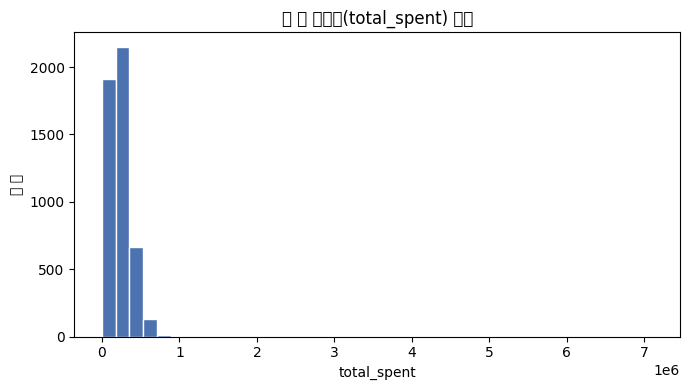

count    4.887000e+03
mean     2.445450e+05
std      2.644495e+05
min      0.000000e+00
25%      1.349855e+05
50%      2.128880e+05
75%      3.119365e+05
max      7.105233e+06
Name: total_spent, dtype: float64


In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(clean["total_spent"], bins=40, color="#4C72B0", edgecolor="white")
ax.set_title("팬 총 지출액(total_spent) 분포")
ax.set_xlabel("total_spent")
ax.set_ylabel("팬 수")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_total_spent_hist.png", dpi=120)
plt.show()

print(clean["total_spent"].describe())

**해석**: 대부분의 팬은 총 지출액 20~30만원대에 몰려 있는 오른쪽 꼬리가 긴(right-skewed) 분포입니다.
평균(약 24만원)이 중앙값보다 높게 나오는 것도 소수의 고액 지출 팬(VIP 등급 등)이 평균을 끌어올리고
있음을 보여줍니다. 이 때문에 앞서 3번 정제 단계에서 상단 이상치를 제거하지 않고 유지한 판단이 뒷받침됩니다.


### 4-2. 범주별 비교 — 구단(`favorite_team`)별 평균 지출액

/tmp/ipykernel_590/531585323.py:17: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/531585323.py:17: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/531585323.py:17: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/531585323.py:17: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/531585323.py:17: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/531585323.py:17: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/531585323.py:17: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

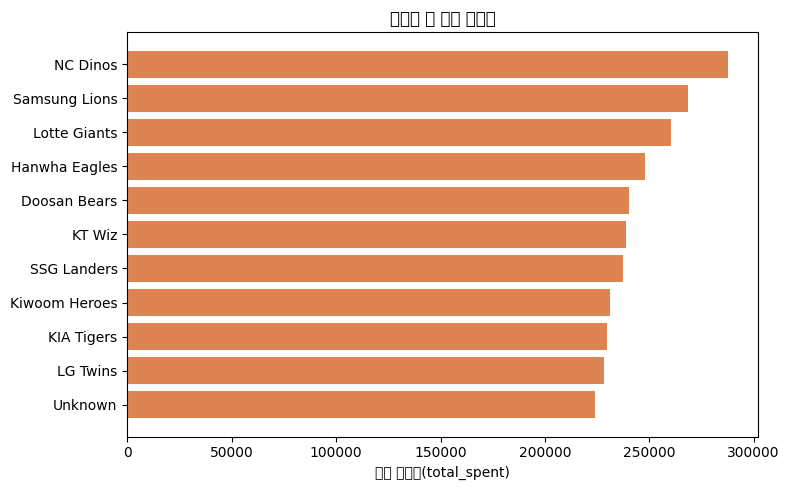

,favorite_team,fan_count,avg_total_spent,avg_attended_games,season_ticket_rate
0,NC Dinos,393,287656.1,10.8,0.5
1,Samsung Lions,486,268435.5,10.7,0.5
2,Lotte Giants,446,260546.8,10.8,0.5
3,Hanwha Eagles,313,248153.7,10.8,0.5
4,Doosan Bears,634,240504.8,10.9,0.5
5,KT Wiz,235,238980.3,11.0,0.5
6,SSG Landers,457,237191.3,11.2,0.5
7,Kiwoom Heroes,405,231355.7,10.9,0.5
8,KIA Tigers,634,229731.9,10.6,0.4
9,LG Twins,785,228183.9,10.6,0.5


In [13]:
team_kpi = (
    clean.groupby("favorite_team")
    .agg(fan_count=("customer_id", "count"),
         avg_total_spent=("total_spent", "mean"),
         avg_attended_games=("attended_games", "mean"),
         season_ticket_rate=("season_ticket_yn", "mean"))
    .round(1)
    .sort_values("avg_total_spent", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(team_kpi["favorite_team"], team_kpi["avg_total_spent"], color="#DD8452")
ax.invert_yaxis()
ax.set_xlabel("평균 지출액(total_spent)")
ax.set_title("구단별 팬 평균 지출액")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_team_avg_spent_bar.png", dpi=120)
plt.show()

team_kpi

**해석**: NC Dinos 팬의 평균 지출액이 가장 높고, 팬 수가 가장 많은 LG Twins는 평균 지출액이 오히려
하위권입니다. 즉 **팬 규모가 큰 구단이 반드시 팬 1인당 지출도 높은 것은 아니다**는 인사이트를 얻을 수
있습니다. 시즌권 보유율은 구단 간 큰 차이 없이 대체로 0.5 근처로 나타나, 이번 샘플에서는 구단 선호가
시즌권 보유 여부와는 뚜렷한 관계를 보이지 않습니다.


### 4-3. 시간 흐름 — 가입연도별 팬 유입 및 평균 지출액

/tmp/ipykernel_590/1340926244.py:19: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/1340926244.py:19: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/1340926244.py:19: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/1340926244.py:19: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/1340926244.py:19: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/1340926244.py:19: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/1340926244.py:19: UserWarning: Glyph 54060 (\N{HANGUL SYLLABLE PAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54060 (\N{HANGUL SYLLABLE PAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

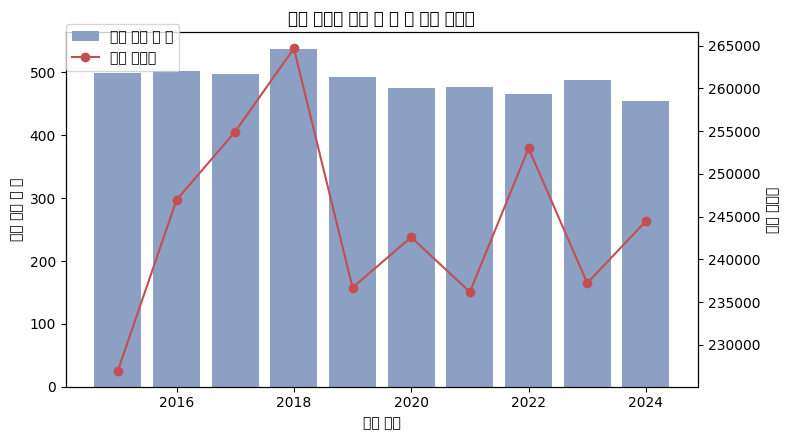

,new_fans,avg_total_spent
join_year,,
2015,499,226988.5
2016,502,246953.6
2017,497,254962.9
2018,537,264685.6
2019,493,236704.8
2020,475,242594.6
2021,477,236188.3
2022,465,253009.7
2023,488,237233.4


In [14]:
clean["join_year"] = clean["join_date"].dt.year
year_trend = (
    clean.groupby("join_year")
    .agg(new_fans=("customer_id", "count"), avg_total_spent=("total_spent", "mean"))
    .round(1)
)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(year_trend.index, year_trend["new_fans"], color="#8CA0C4", label="신규 가입 팬 수")
ax1.set_xlabel("가입 연도")
ax1.set_ylabel("신규 가입 팬 수")

ax2 = ax1.twinx()
ax2.plot(year_trend.index, year_trend["avg_total_spent"], color="#C44E52", marker="o", label="평균 지출액")
ax2.set_ylabel("평균 지출액")

ax1.set_title("가입 연도별 신규 팬 수 및 평균 지출액")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.95))
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_year_trend.png", dpi=120)
plt.show()

year_trend

**해석**: 가입 연도가 최근일수록 평균 지출액이 뚜렷하게 높아지거나 낮아지는 일관된 추세는 보이지
않습니다. 다만 연도별 신규 가입 팬 수는 특정 연도에 몰리는 구간이 있어, 이 데이터가 실제 마케팅
이벤트나 프로모션 시점과 연결되는지는 이 데이터만으로는 확인할 수 없습니다(6번 한계 참고).


### 4-4. 핵심 KPI 요약 — 멤버십 등급별

In [15]:
membership_kpi = (
    clean.groupby("membership_tier")
    .agg(fan_count=("customer_id", "count"),
         avg_total_spent=("total_spent", "mean"),
         avg_attended_games=("attended_games", "mean"))
    .round(1)
    .reset_index()
)
membership_kpi

,membership_tier,fan_count,avg_total_spent,avg_attended_games
0,Bronze,1863,249320.9,10.8
1,Gold,904,242506.0,10.7
2,Silver,1412,243592.4,10.8
3,Unknown,245,246106.3,10.9
4,VIP,463,231387.8,10.8


**해석(인사이트 요약)**

1. **구단별 팬 수와 팬 1인당 평균 지출액은 서로 다른 신호다.** LG Twins·KIA Tigers는 팬 수가 가장
   많지만 평균 지출은 하위권, NC Dinos는 팬 수는 중간이지만 평균 지출은 1위다. 마케팅 관점에서
   "팬이 많은 구단"과 "지출 여력이 큰 팬층을 가진 구단"을 구분해서 봐야 한다.
2. **멤버십 등급(Bronze~VIP)과 평균 지출액이 뚜렷한 정비례 관계를 보이지 않는다.** VIP 등급의 평균
   지출액이 Bronze/Silver보다 오히려 낮게 나타나, `membership_tier`가 순수 소비액 기준으로 매겨진
   등급이 아닐 가능성을 시사한다 (가입 기간, 프로모션 코드 등 다른 기준일 수 있음 — 후속 확인 필요).


## 5. 결과 저장

정제 데이터와 KPI 요약을 Parquet으로 저장하고, 같은 데이터를 CSV로도 저장해 용량을 비교합니다.

In [16]:
clean.to_parquet(f"{OUT_DIR}/cleaned_data.parquet", index=False)
clean.to_csv(f"{OUT_DIR}/cleaned_data_for_size_check.csv", index=False)

team_kpi.to_parquet(f"{OUT_DIR}/kpi_team_summary.parquet", index=False)
membership_kpi.to_parquet(f"{OUT_DIR}/kpi_membership_summary.parquet", index=False)
year_trend.reset_index().to_parquet(f"{OUT_DIR}/kpi_year_trend_summary.parquet", index=False)

csv_size = os.path.getsize(f"{OUT_DIR}/cleaned_data_for_size_check.csv")
parquet_size = os.path.getsize(f"{OUT_DIR}/cleaned_data.parquet")
print(f"CSV 용량: {csv_size:,} bytes")
print(f"Parquet 용량: {parquet_size:,} bytes")
print(f"Parquet이 CSV의 약 {parquet_size/csv_size:.1%} 크기 (약 1/{csv_size/parquet_size:.1f})")

os.remove(f"{OUT_DIR}/cleaned_data_for_size_check.csv")  # 용량 비교용 임시 파일 정리

CSV 용량: 551,960 bytes
Parquet 용량: 140,488 bytes
Parquet이 CSV의 약 25.5% 크기 (약 1/3.9)


**한 줄 비교**: Parquet 파일이 CSV보다 훨씬 작고(용량 비교 결과는 위 출력 참고), 날짜 컬럼의
`datetime64[ns]` 자료형도 그대로 보존되어 다음 분석가가 다시 `pd.to_datetime()`을 호출할 필요가 없습니다.


## 6. 한계와 후속 질문

- **membership_tier 산정 기준을 알 수 없다.** EDA에서 등급과 평균 지출액이 정비례하지 않는 현상을
  발견했지만, 이 데이터만으로는 등급이 어떤 기준(가입 기간? 프로모션? 다른 채널?)으로 부여됐는지
  알 수 없어 원인을 단정할 수 없다. 등급 산정 로직 문서가 있다면 함께 봐야 한다.
- **가입 연도별 유입 추이의 원인을 설명할 변수가 없다.** 특정 연도에 신규 가입이 몰리는 패턴이
  보였지만, 프로모션·마케팅 캠페인·구단 성적 등 외부 요인 데이터가 없어 "왜" 몰렸는지는 추정만 가능하다.
- **동일 customer_id 스냅샷 충돌(25건)을 "최근 날짜 우선"으로만 해소했다.** 어떤 필드가 실제로
  바뀌었는지(지역 이전? 등급 변경?) 변경 이력 자체는 분석하지 않았다. 후속 분석에서는 필드별
  변경 내역을 diff로 추적해 볼 수 있다.
- **email 컬럼을 제거하여 유입 경로(referral_source)와 실제 채널 데이터를 연결하는 정밀 분석은
  하지 못했다.** 개인정보 보호가 우선이므로 이는 의도된 제약이다.
- 다음 분석에서는 구단 성적(순위·플레이오프 진출 여부)이나 시즌별 프로모션 정보를 추가로 확보하면,
  지출·유입 패턴의 원인을 더 설명력 있게 해석할 수 있을 것이다.
